In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [43]:
df  = pd.read_csv("../datasets/home_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Exploring the data for housing sales

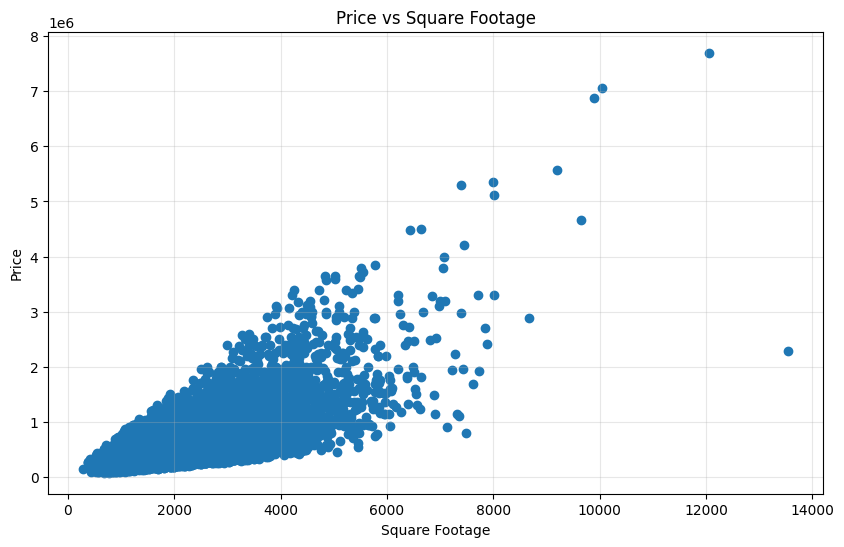

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df["sqft_living"], y=df["price"])
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.title("Price vs Square Footage")
plt.grid(alpha=0.3)
plt.show()

# Create a simple regression model of sqft_living to price

In [45]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [46]:
Y = df["price"]
X = df[['sqft_living']]
X
train_data, test_data, train_labels, test_labels = train_test_split(X, Y, test_size=0.2, random_state=42)

In [47]:
train_data.shape, test_data.shape, train_labels.shape, test_labels.shape

((17290, 1), (4323, 1), (17290,), (4323,))

In [48]:
slr = LinearRegression(fit_intercept=True)
slr.fit(train_data, train_labels)

LinearRegression()

# Evaluate the simple model

In [49]:
slr.score(test_data, test_labels)

0.4940690470123985

In [50]:
slr.coef_, slr.intercept_

(array([279.55477851]), -41999.18454229331)

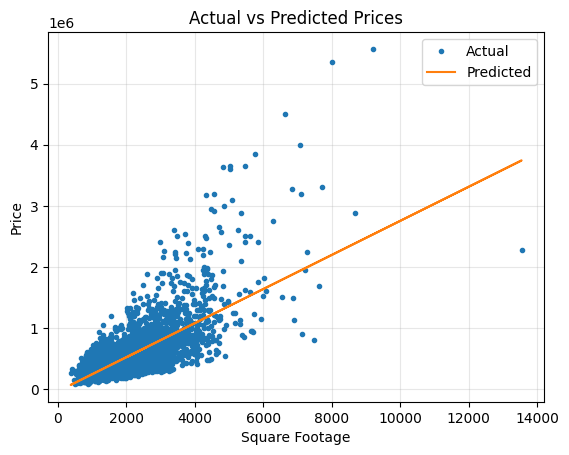

In [51]:
plt.plot(test_data, test_labels, '.', label='Actual')
plt.plot(test_data, slr.predict(test_data), '-', label='Predicted')
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Explore other features in the data

In [53]:
features = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "zipcode"]

df.loc[:, 'zipcode'] = df.loc[ :, 'zipcode'].astype('str')
df.loc[:, 'zipcode'].describe()

/var/folders/13/52nlj_0n1dlcbpr9zv8m5k3w0000gn/T/ipykernel_2843/3203193031.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['98178' '98125' '98028' ... '98144' '98027' '98144']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'zipcode'] = df.loc[ :, 'zipcode'].astype('str')


count     21613
unique       70
top       98103
freq        602
Name: zipcode, dtype: object

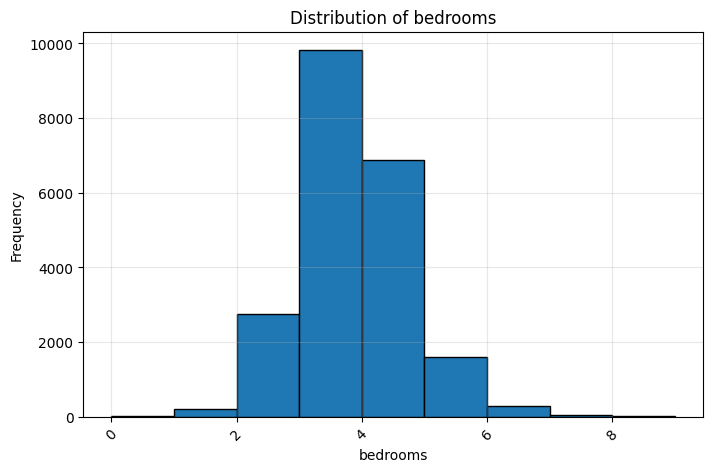

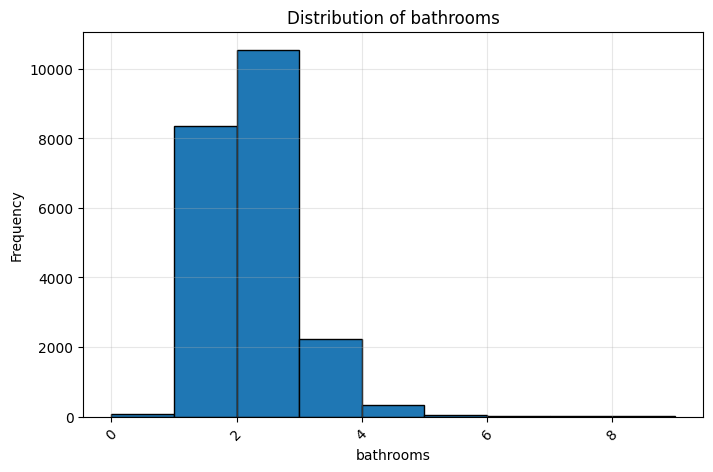

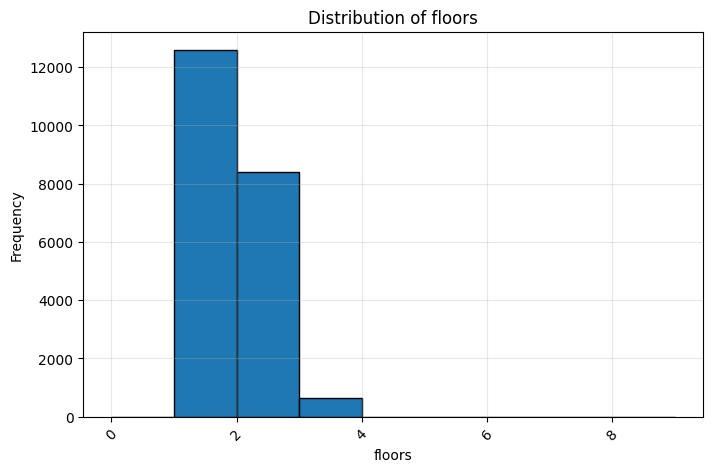

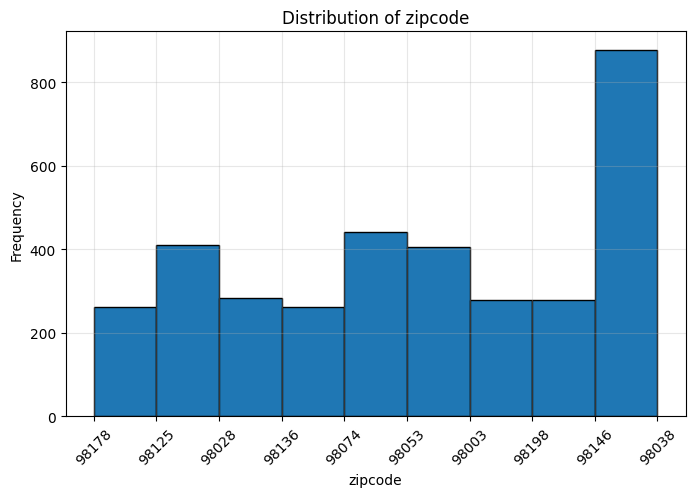

In [13]:
for feature in ["bedrooms", "bathrooms", "floors", "zipcode"]:
    plt.figure(figsize=(8, 5))
    plt.hist(df[feature], bins=range(0, 10), edgecolor="black")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()

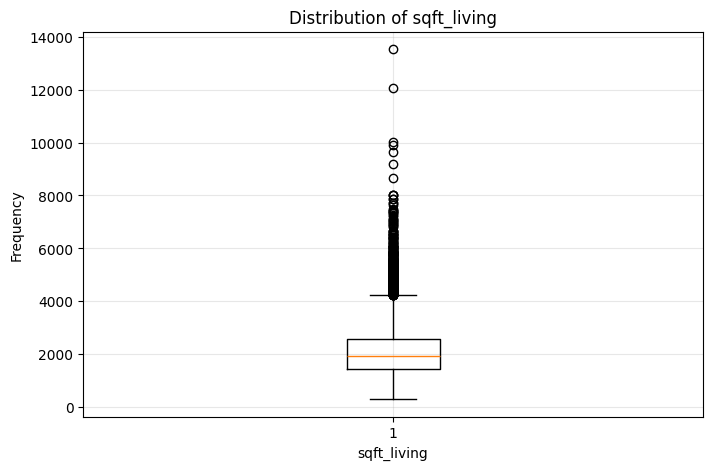

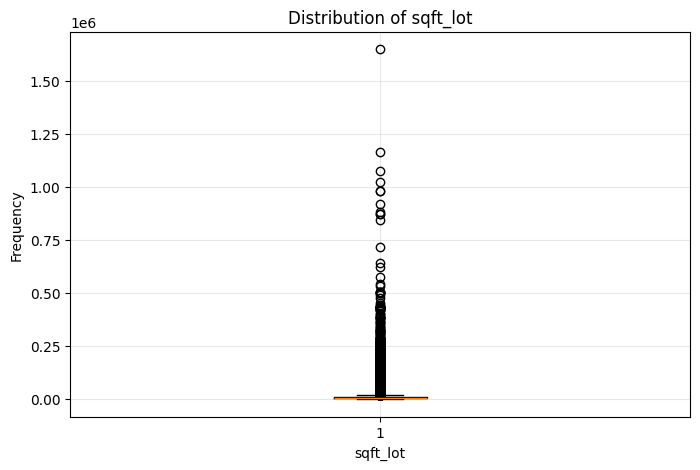

In [14]:
for feature in ["sqft_living", "sqft_lot"]:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[feature])
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

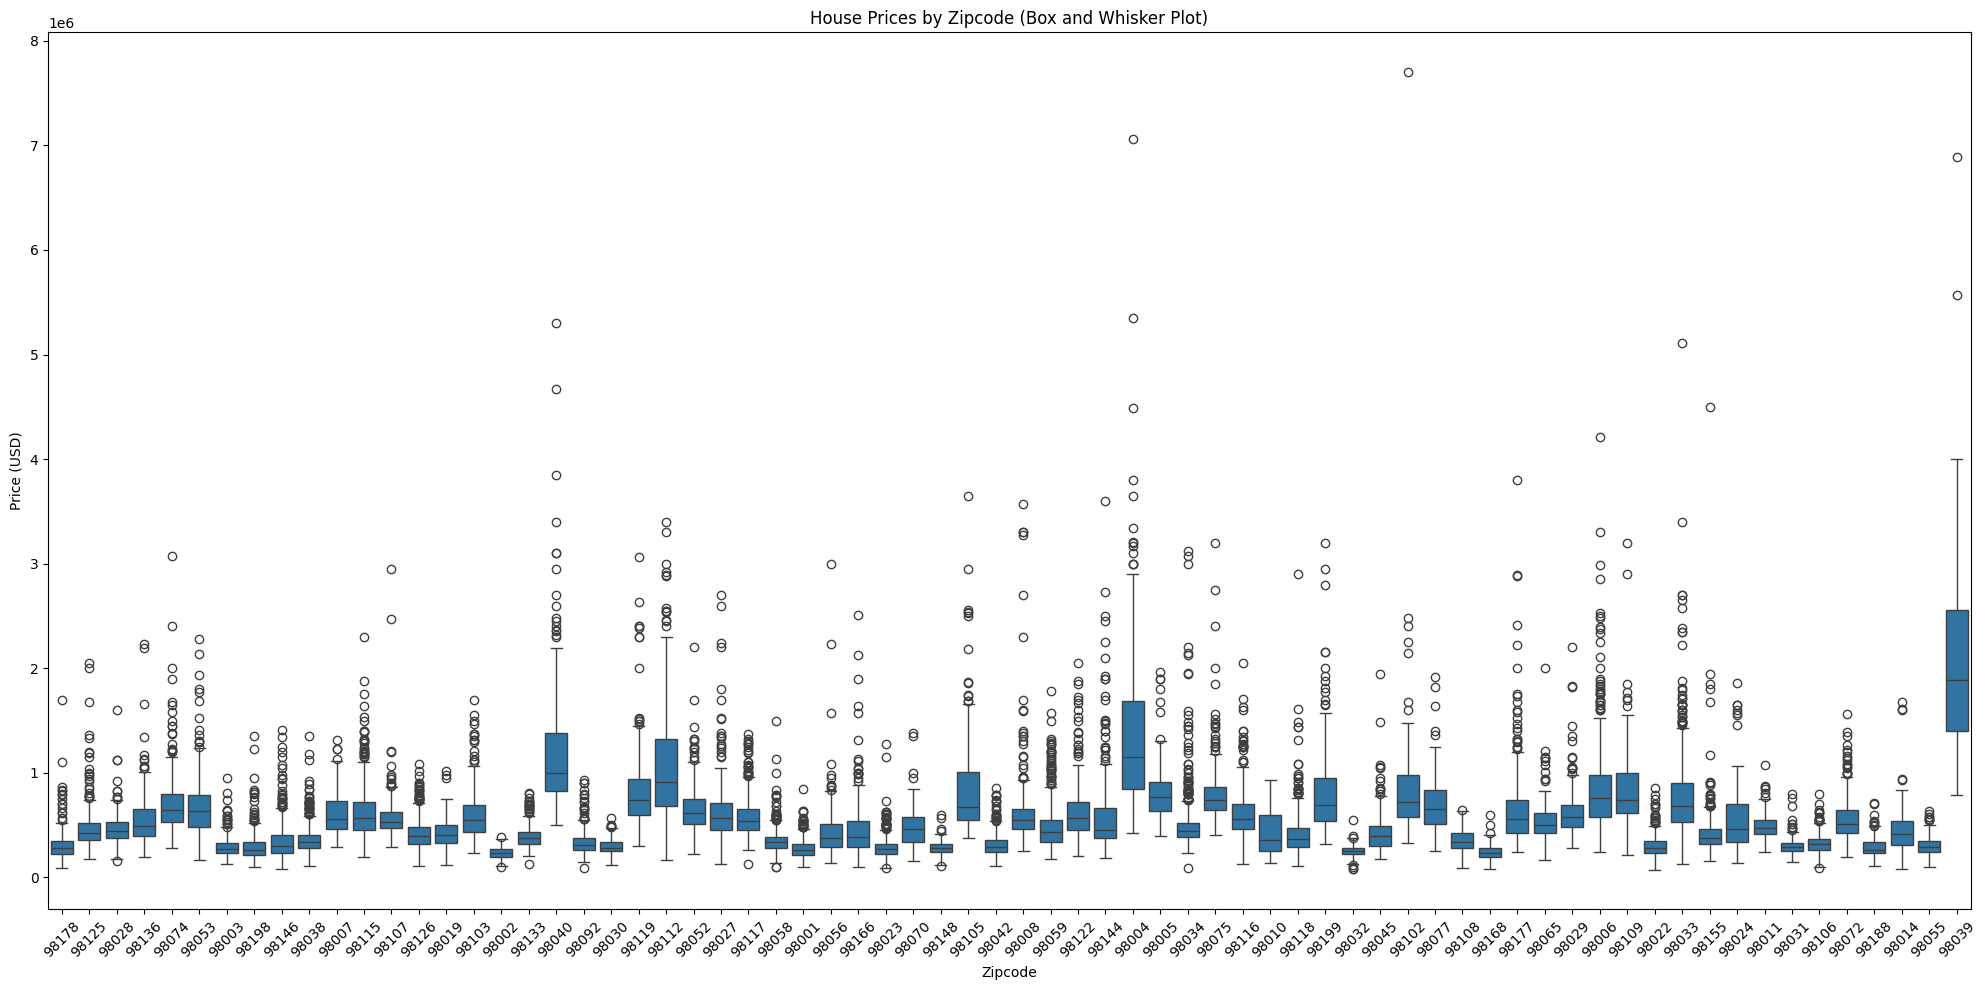

In [15]:
plt.figure(figsize=(20, 10))   # Large figure because there are many zipcodes

sns.boxplot(x='zipcode', y='price', data=df)

plt.title('House Prices by Zipcode (Box and Whisker Plot)')
plt.xlabel('Zipcode')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)       # Rotate x labels so they don't overlap
plt.tight_layout()
plt.show()

# Build a regression model with more features

In [16]:
X = df[features]
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,zipcode
0,3,1.00,1180,5650,1.0,98178
1,3,2.25,2570,7242,2.0,98125
2,2,1.00,770,10000,1.0,98028
3,4,3.00,1960,5000,1.0,98136
4,3,2.00,1680,8080,1.0,98074


In [17]:
train_data_mlr, test_data_mlr, train_labels_mlr, test_labels_mlr = train_test_split(X, Y, test_size=0.2, random_state=40)
train_data_mlr.shape, test_data_mlr.shape, train_labels_mlr.shape, test_labels_mlr.shape

((17290, 6), (4323, 6), (17290,), (4323,))

In [18]:
mlr = LinearRegression()
mlr.fit(train_data_mlr, train_labels_mlr)

LinearRegression()

In [19]:
mlr.score(test_data_mlr, test_labels_mlr)

0.521155002321316

In [20]:
mlr.coef_, mlr.intercept_

(array([-6.09006506e+04,  1.35433589e+04,  3.19228644e+02, -2.81385311e-01,
        -4.12230344e+03,  5.62534216e+02]),
 -55108851.554074444)

In [29]:
test_labels_mlr.iloc[2]

440000

In [30]:
slr.predict(test_data.iloc[2].values.reshape(1, -1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1011922.33043837])

In [31]:
mlr.predict(test_data_mlr.iloc[2].values.reshape(1, -1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([467010.19662097])

In [74]:
df.loc[:, features][df.loc[:, features][df["sqft_living"] >= 2000] and df.loc[:, features][df["sqft_living"] >= 2000]]

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [73]:
filtered_df = df.loc[(df["sqft_living"] >= 2000) & (df["sqft_living"] <= 4000), features]
(filtered_df.shape[0] / df[features].shape[0]) * 100

42.66413732475825